# Q3A. Sonic Signatures, 'Magical Mystery Tune'

This notebook builds a simple song fingerprinting and identification system, similar in idea
to apps like Shazam. It computes a spectrogram, picks out the strongest time-frequency
peaks (the constellation map), pairs nearby peaks into compact hashes, stores them in a
database, and matches a query clip against the database using an offset histogram. It also
tests how robust the matcher is to noise, pitch shift, and time stretch, and compares pair
based matching against single peak matching.

**Libraries**

In [1]:
import pandas as pd
import numpy as np
import cv2
import librosa
import matplotlib.pyplot as plt

**Importing Song**

Sampling Rate:44100


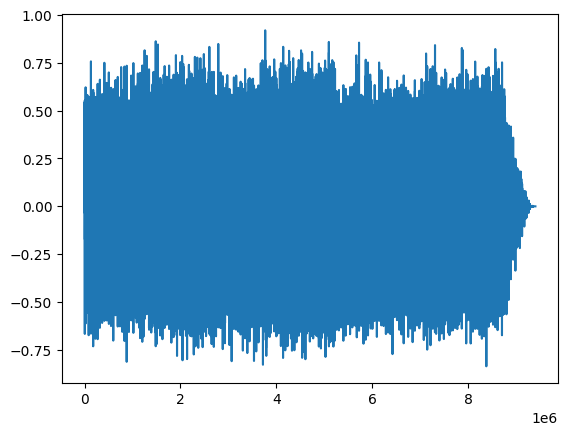

In [2]:
audio,sr = librosa.load("Never Gonna Give You Up.mp3",sr=None)

# Sampling rate of audio
print(f"Sampling Rate:{sr}")

# A visual plot of audio
plt.plot(audio[:])

plt.show()

**Computing Fourier Transforms**

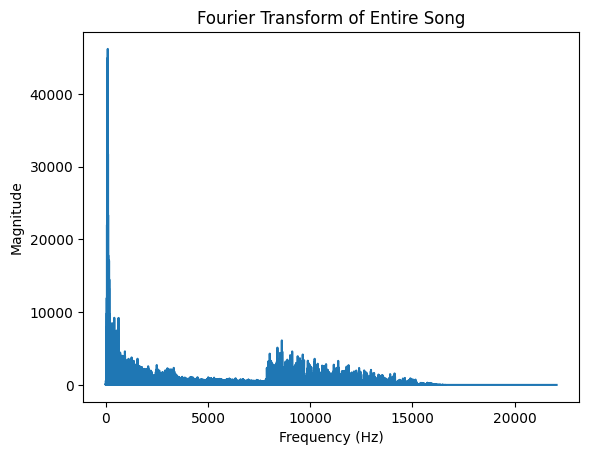

In [3]:
F = np.fft.rfft(audio)
F_mag = np.abs(F)
freqs = np.fft.rfftfreq(len(audio), d=1/sr)
plt.plot(freqs,F_mag)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Fourier Transform of Entire Song")
plt.show()


**The above graph gives no useful insights in determining the song**

*So we have to make a unique image which corresponds to the song*

**Doing a transform over a window of length 2048 hopping over 512 intervals**

[[-80. -80. -80. ... -80. -80. -80.]
 [-80. -80. -80. ... -80. -80. -80.]
 [-80. -80. -80. ... -80. -80. -80.]
 ...
 [-80. -80. -80. ... -80. -80. -80.]
 [-80. -80. -80. ... -80. -80. -80.]
 [-80. -80. -80. ... -80. -80. -80.]]


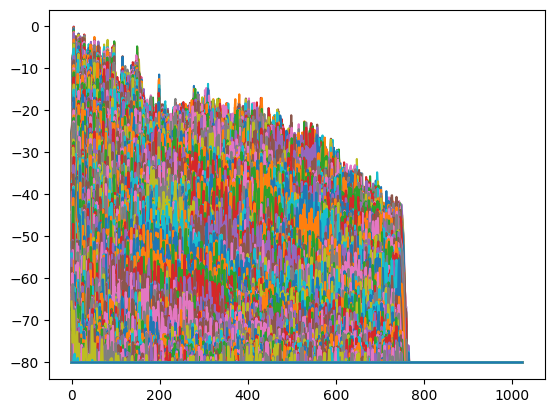

In [4]:
D = librosa.stft(
        audio,
        n_fft=2048,
        hop_length=512
)

S_db = librosa.amplitude_to_db(
            np.abs(D),
            ref=np.max
)

print(S_db)
plt.plot((S_db[:]))
plt.show()

**Plotting the spectrogram**

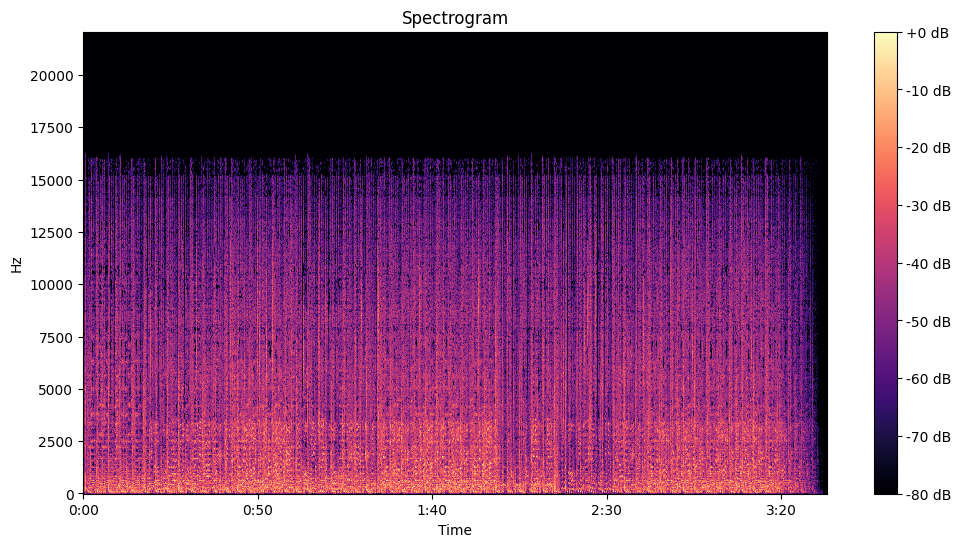

In [5]:
plt.figure(figsize=(12, 6))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram")
plt.show()

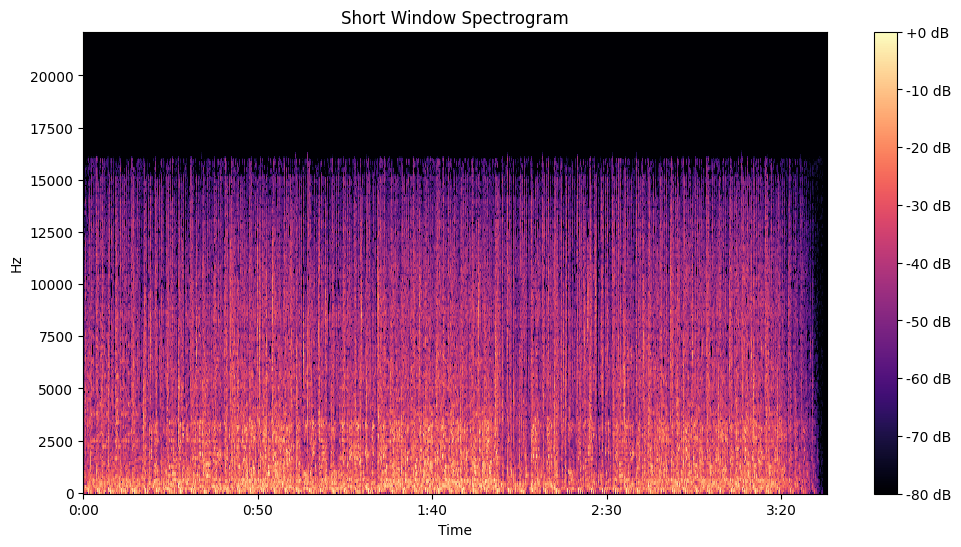

In [6]:
D_short = librosa.stft(
    audio,
    n_fft=512,
    hop_length=128
)

S_short_db = librosa.amplitude_to_db(
    np.abs(D_short),
    ref=np.max
)

plt.figure(figsize=(12,6))

librosa.display.specshow(
    S_short_db,
    sr=sr,
    hop_length=128,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Short Window Spectrogram")
plt.show()

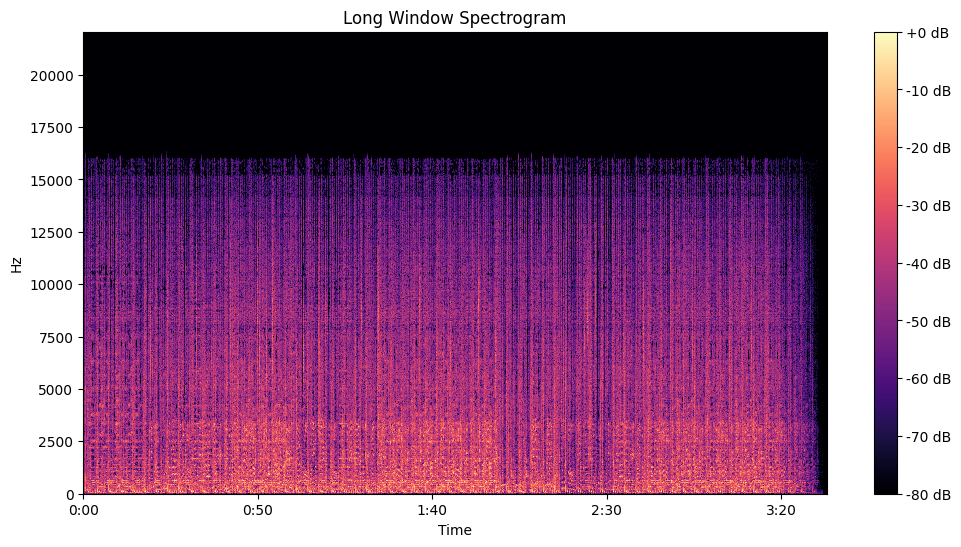

In [7]:
D_long = librosa.stft(
    audio,
    n_fft=4096,
    hop_length=1024
)

S_long_db = librosa.amplitude_to_db(
    np.abs(D_long),
    ref=np.max
)

plt.figure(figsize=(12,6))

librosa.display.specshow(
    S_long_db,
    sr=sr,
    hop_length=1024,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Long Window Spectrogram")
plt.show()

**Observation: effect of window length**

Comparing the three spectrograms above:

- Window 2048 (hop 512), the normal one, gives a good balance, frequency bands are sharp
enough to read and timing is still reasonably precise.
- Window 512 (hop 128), the short window, gives sharper timing (we can see fast changes
clearly) but the frequency bands look more blurred and spread out vertically, frequency
resolution is poor.
- Window 4096 (hop 1024), the long window, gives very sharp, thin frequency bands (good
frequency resolution) but the timing looks smeared, fast changes in the signal get blurred
together horizontally.

This is the usual time vs frequency resolution trade off, a short window localizes time well
but spreads frequency, a long window localizes frequency well but spreads time. The window
size of 2048 was picked for the rest of this notebook as a reasonable middle point that still
gives clean, identifiable peaks for fingerprinting.

**Plotting only the high frequency points**

In [8]:
from scipy.ndimage import maximum_filter

S = np.abs(D)
local_max = maximum_filter(S, size=20)
threshold = np.percentile(S, 99.5)
peaks = (S == local_max) & (S > threshold)

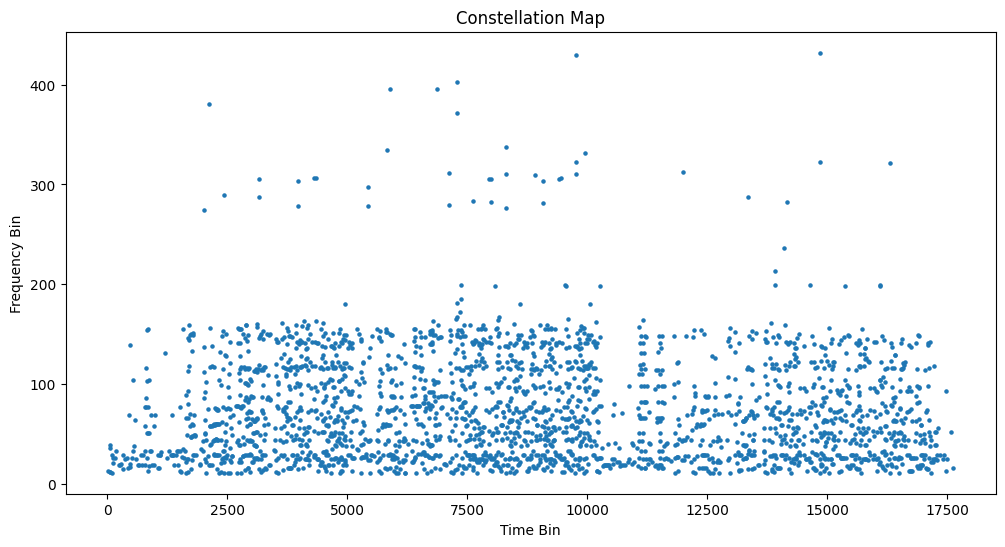

In [9]:
coords = np.argwhere(peaks)

# Ignore the first few frequency bins
coords = coords[coords[:,0] > 10]

plt.figure(figsize=(12,6))
plt.scatter(coords[:,1], coords[:,0], s=5)
plt.xlabel("Time Bin")
plt.ylabel("Frequency Bin")
plt.title("Constellation Map")
plt.show()

**Clubbing the Logic together into one function**

In [10]:
import librosa
import numpy as np
from scipy.ndimage import maximum_filter

def get_fingerprints(filepath):

    audio, sr = librosa.load(filepath, sr=None)
    D = librosa.stft(
        audio,
        n_fft=2048,
        hop_length=512
    )

    S = np.abs(D)
    local_max = maximum_filter(S, size=20)
    threshold = np.percentile(S, 99.5)
    peaks = (S == local_max) & (S > threshold)
    coords = np.argwhere(peaks)
    hashes = []

    for i in range(len(coords)):
        f1, t1 = coords[i]
        for j in range(i+1, min(i+11, len(coords))):
            f2, t2 = coords[j]
            hashes.append(
                (int(f1), int(f2), int(t2-t1))
            )

    return hashes

**Adressing the songs one-by-one and adding them into database**

In [11]:
import os
song_folder = "."
database = {}

for file in os.listdir(song_folder):
    if file.endswith(".mp3"):
        path = os.path.join(song_folder, file)
        database[file] = get_fingerprints(path)

        print(
            file,
            len(database[file])
        )

A Day In The Life.mp3 25875
A Hard Day_s Night.mp3 21305
Across The Universe.mp3 23485
Back In The U.S.S.R..mp3 21115
Blackbird.mp3 9425
Bohemian Rhapsody.mp3 23225
Can_t Buy Me Love.mp3 17585
Crazy Little Thing Called Love.mp3 13245
Day Tripper.mp3 22285
Don_t Stop Me Now.mp3 32875
Drive My Car.mp3 18785
Eight Days A Week.mp3 21605
Eleanor Rigby.mp3 14945
Get Back.mp3 17935
Hello, Goodbye.mp3 29265
Help!.mp3 18025
Helter Skelter.mp3 43695
Hey Jude.mp3 56185
I Am The Walrus.mp3 32275
I Saw Her Standing There.mp3 26215
I Want It All.mp3 33735
I Want To Hold Your Hand.mp3 22085
In My Life.mp3 12575
I_ll Follow The Sun.mp3 9105
I_ve Got A Feeling.mp3 23615
Killer Queen.mp3 20195
Let It Be.mp3 24835
Love Me Do.mp3 15175
Lucy In The Sky With Diamonds.mp3 25085
Never Gonna Give You Up.mp3 31925
Norwegian Wood (This Bird Has Flown).mp3 11585
Penny Lane.mp3 24585
Radio Ga Ga.mp3 34175
Revolution.mp3 25105
Sgt. Pepper_s Lonely Hearts Club Band.mp3 15005
She Said She Said.mp3 21705
Somebody To L

In [12]:
def get_fingerprints_audio(audio):

    D = librosa.stft(
        audio,
        n_fft=2048,
        hop_length=512
    )

    S = np.abs(D)

    local_max = maximum_filter(S, size=20)
    threshold = np.percentile(S, 99.5)

    peaks = (S == local_max) & (S > threshold)
    coords = np.argwhere(peaks)

    hashes = []

    for i in range(len(coords)):
        f1, t1 = coords[i]

        for j in range(i + 1, min(i + 15, len(coords))):
            f2, t2 = coords[j]

            hashes.append(
                (int(f1), int(f2), int(t2 - t1))
            )

    return hashes

**Saving the database if needed**

In [13]:
import pickle
with open("fingerprint_db.pkl", "wb") as f:
    pickle.dump(database, f)
print("Database saved")

Database saved


**Checking the saved database**

In [14]:
import pickle

with open("fingerprint_db.pkl", "rb") as f:
    database = pickle.load(f)

print(f"Number of Songs:{len(database)}")
print(database.keys())

Number of Songs:50
dict_keys(['A Day In The Life.mp3', 'A Hard Day_s Night.mp3', 'Across The Universe.mp3', 'Back In The U.S.S.R..mp3', 'Blackbird.mp3', 'Bohemian Rhapsody.mp3', 'Can_t Buy Me Love.mp3', 'Crazy Little Thing Called Love.mp3', 'Day Tripper.mp3', 'Don_t Stop Me Now.mp3', 'Drive My Car.mp3', 'Eight Days A Week.mp3', 'Eleanor Rigby.mp3', 'Get Back.mp3', 'Hello, Goodbye.mp3', 'Help!.mp3', 'Helter Skelter.mp3', 'Hey Jude.mp3', 'I Am The Walrus.mp3', 'I Saw Her Standing There.mp3', 'I Want It All.mp3', 'I Want To Hold Your Hand.mp3', 'In My Life.mp3', 'I_ll Follow The Sun.mp3', 'I_ve Got A Feeling.mp3', 'Killer Queen.mp3', 'Let It Be.mp3', 'Love Me Do.mp3', 'Lucy In The Sky With Diamonds.mp3', 'Never Gonna Give You Up.mp3', 'Norwegian Wood (This Bird Has Flown).mp3', 'Penny Lane.mp3', 'Radio Ga Ga.mp3', 'Revolution.mp3', 'Sgt. Pepper_s Lonely Hearts Club Band.mp3', 'She Said She Said.mp3', 'Somebody To Love.mp3', 'Something.mp3', 'Taxman.mp3', 'The Long And Winding Road.mp3', '

**Making a query to check if it works**

In [15]:
audio, sr = librosa.load(
    "Never Gonna Give You Up.mp3",
    sr=None
)

query_song = audio[
    30*sr : 40*sr
]

query_hashes = get_fingerprints_audio(query_song)
query_set = set(query_hashes)

In [16]:
scores = {}

for song, song_hashes in database.items():
    song_set = set(song_hashes)

    matches = len(
        query_set.intersection(song_set)
    )
    scores[song] = matches

In [17]:
sorted_scores = sorted(
    scores.items(),
    key=lambda x: x[1],
    reverse=True
)

for song, score in sorted_scores[:]:
    print(song, score)

Never Gonna Give You Up.mp3 230
I Saw Her Standing There.mp3 69
Drive My Car.mp3 67
Hello, Goodbye.mp3 67
Somebody To Love.mp3 66
Back In The U.S.S.R..mp3 65
A Day In The Life.mp3 64
Eight Days A Week.mp3 63
Get Back.mp3 63
Revolution.mp3 63
Can_t Buy Me Love.mp3 62
I Am The Walrus.mp3 61
I_ve Got A Feeling.mp3 61
Penny Lane.mp3 60
Within You Without You.mp3 57
Lucy In The Sky With Diamonds.mp3 56
We Are The Champions.mp3 56
Hey Jude.mp3 55
Radio Ga Ga.mp3 52
Help!.mp3 48
Day Tripper.mp3 47
While My Guitar Gently Weeps.mp3 46
Helter Skelter.mp3 43
Let It Be.mp3 39
Sgt. Pepper_s Lonely Hearts Club Band.mp3 39
With A Little Help From My Friends.mp3 39
She Said She Said.mp3 36
Something.mp3 36
In My Life.mp3 34
Bohemian Rhapsody.mp3 32
I Want It All.mp3 31
Two Of Us.mp3 30
Across The Universe.mp3 27
Don_t Stop Me Now.mp3 26
We Can Work It Out.mp3 26
Norwegian Wood (This Bird Has Flown).mp3 18
The Long And Winding Road.mp3 18
I Want To Hold Your Hand.mp3 16
Taxman.mp3 15
A Hard Day_s Night

In [18]:
correct = 0
total = 0

for song in database.keys():

    try:
        audio, sr = librosa.load(song, sr=None)

        # Agar song 40 sec se chhota hai to skip kar do
        if len(audio) < 40 * sr:
            print(f"Skipped: {song} (too short)")
            continue

        query_song = audio[30 * sr : 40 * sr]

        query_hashes = get_fingerprints_audio(query_song)
        query_set = set(query_hashes)

        scores = {}

        for db_song, song_hashes in database.items():
            song_set = set(song_hashes)

            matches = len(
                query_set.intersection(song_set)
            )

            scores[db_song] = matches

        predicted = max(scores, key=scores.get)

        print(
            f"Actual: {song} | Predicted: {predicted}"
        )

        if predicted == song:
            correct += 1

        total += 1

    except Exception as e:
        print(f"Error in {song}: {e}")

print("\n" + "="*50)
print(f"Correct Predictions : {correct}")
print(f"Total Tested        : {total}")

if total > 0:
    print(f"Accuracy            : {100*correct/total:.2f}%")
else:
    print("No songs were tested.")

Actual: A Day In The Life.mp3 | Predicted: A Day In The Life.mp3
Actual: A Hard Day_s Night.mp3 | Predicted: A Hard Day_s Night.mp3
Actual: Across The Universe.mp3 | Predicted: Across The Universe.mp3
Actual: Back In The U.S.S.R..mp3 | Predicted: Back In The U.S.S.R..mp3
Actual: Blackbird.mp3 | Predicted: Blackbird.mp3
Actual: Bohemian Rhapsody.mp3 | Predicted: Bohemian Rhapsody.mp3
Actual: Can_t Buy Me Love.mp3 | Predicted: Can_t Buy Me Love.mp3
Actual: Crazy Little Thing Called Love.mp3 | Predicted: Crazy Little Thing Called Love.mp3
Actual: Day Tripper.mp3 | Predicted: Day Tripper.mp3
Actual: Don_t Stop Me Now.mp3 | Predicted: Don_t Stop Me Now.mp3
Actual: Drive My Car.mp3 | Predicted: Drive My Car.mp3
Actual: Eight Days A Week.mp3 | Predicted: Eight Days A Week.mp3
Actual: Eleanor Rigby.mp3 | Predicted: Eleanor Rigby.mp3
Actual: Get Back.mp3 | Predicted: Get Back.mp3
Actual: Hello, Goodbye.mp3 | Predicted: Hello, Goodbye.mp3
Actual: Help!.mp3 | Predicted: Help!.mp3
Actual: Helter S

In [19]:
best_song = sorted_scores[0][0]

print("Matched Song:", best_song)

Matched Song: Never Gonna Give You Up.mp3


## Improving the matching: using offset histograms

For every matching hash, we compute the offset between the database timestamp and query timestamp. Correct matches produce a dominant offset peak.

In [20]:
import librosa
import numpy as np
from scipy.ndimage import maximum_filter

def get_fingerprints_with_time(audio_input, sr=None, is_path=True):
    """
    Same fingerprinting idea as get_fingerprints, but also returns the time bin
    of each hash, needed to build the offset histogram during matching.

    Returns a list of (hash, time_bin) tuples, where hash = (f1, f2, dt)
    """

    if is_path:
        audio, sr = librosa.load(audio_input, sr=None)
    else:
        audio = audio_input

    D = librosa.stft(
        audio,
        n_fft=2048,
        hop_length=512
    )

    S = np.abs(D)

    local_max = maximum_filter(S, size=20)
    threshold = np.percentile(S, 99.5)
    peaks = (S == local_max) & (S > threshold)

    coords = np.argwhere(peaks)
    coords = coords[coords[:, 0] > 10]

    # sort by time bin so pairing nearby peaks makes sense
    coords = coords[np.argsort(coords[:, 1])]

    hashes = []

    for i in range(len(coords)):
        f1, t1 = coords[i]

        for j in range(i + 1, min(i + 15, len(coords))):
            f2, t2 = coords[j]

            h = (int(f1), int(f2), int(t2 - t1))
            hashes.append((h, int(t1)))

    return hashes

**Rebuilding the database with time information**

We rebuild the database using the new function, so each song's fingerprints now carry
their time bin. We store the database as a dictionary that maps each hash to a list of
(song name, time bin) pairs, this is the usual way to structure a fingerprint database
since it lets us look up a hash and instantly see every song and time it occurred in,
instead of looping through every song one by one.

In [21]:
import os
song_folder = "."

# hash_db: hash -> list of (song_name, time_bin)
hash_db = {}

# also keep raw per song fingerprints for the single-peak comparison later
song_fingerprints_with_time = {}

for file in os.listdir(song_folder):

    if file.endswith(".mp3"):

        path = os.path.join(song_folder, file)

        fps = get_fingerprints_with_time(path, is_path=True)
        song_fingerprints_with_time[file] = fps

        for h, t in fps:
            if h not in hash_db:
                hash_db[h] = []
            hash_db[h].append((file, t))

        print(file, len(fps))

A Day In The Life.mp3 25179
A Hard Day_s Night.mp3 22897
Across The Universe.mp3 25319
Back In The U.S.S.R..mp3 21133
Blackbird.mp3 7847
Bohemian Rhapsody.mp3 26971
Can_t Buy Me Love.mp3 18361
Crazy Little Thing Called Love.mp3 12789
Day Tripper.mp3 22701
Don_t Stop Me Now.mp3 35497
Drive My Car.mp3 19495
Eight Days A Week.mp3 24129
Eleanor Rigby.mp3 17507
Get Back.mp3 17759
Hello, Goodbye.mp3 32725
Help!.mp3 19551
Helter Skelter.mp3 48531
Hey Jude.mp3 63665
I Am The Walrus.mp3 33663
I Saw Her Standing There.mp3 28343
I Want It All.mp3 37387
I Want To Hold Your Hand.mp3 24899
In My Life.mp3 12243
I_ll Follow The Sun.mp3 9681
I_ve Got A Feeling.mp3 24423
Killer Queen.mp3 22141
Let It Be.mp3 27517
Love Me Do.mp3 16415
Lucy In The Sky With Diamonds.mp3 28441
Never Gonna Give You Up.mp3 36449
Norwegian Wood (This Bird Has Flown).mp3 10521
Penny Lane.mp3 26551
Radio Ga Ga.mp3 30667
Revolution.mp3 24647
Sgt. Pepper_s Lonely Hearts Club Band.mp3 15603
She Said She Said.mp3 24409
Somebody To L

**Saving the new database**

Same as before, saved using pickle so it does not need to be rebuilt every time.

In [22]:
import pickle

with open("hash_db.pkl", "wb") as f:
    pickle.dump(hash_db, f)

with open("song_fingerprints_with_time.pkl", "wb") as f:
    pickle.dump(song_fingerprints_with_time, f)

print("Saved hash_db.pkl and song_fingerprints_with_time.pkl")

Saved hash_db.pkl and song_fingerprints_with_time.pkl


**Matching function using the offset histogram**

For a query clip, we find every hash that also exists in the database, and for every match
we compute the offset (song time bin minus query time bin). If the query really is a clip
from that song, almost all matching hashes will agree on the same offset (since the whole
clip is shifted in time by a fixed amount relative to the original song), so the histogram
of offsets for the correct song will have one tall, sharp peak. For a wrong song, matches
happen by chance at random positions, so the offset histogram will look flat and scattered.

The function below returns, for every candidate song, the highest bin in its offset
histogram, this is the score we use to decide the match, instead of just raw hash count.

In [23]:
from collections import defaultdict

def match_query(query_hashes_with_time, hash_db):
    """
    query_hashes_with_time: list of (hash, time_bin) from get_fingerprints_with_time
    Returns: dict of song -> best offset histogram peak count
             also returns the full offset histograms for plotting
    """

    offset_counts = defaultdict(lambda: defaultdict(int))

    for h, t_query in query_hashes_with_time:
        if h in hash_db:
            for song, t_song in hash_db[h]:
                offset = t_song - t_query
                offset_counts[song][offset] += 1

    scores = {}
    for song, hist in offset_counts.items():
        best_offset = max(hist, key=hist.get)
        scores[song] = hist[best_offset]

    return scores, offset_counts

**Testing the offset histogram matching on a query clip**

We take a 10 second clip from a known song (same as the earlier basic test) and run it
through the new matching function.

In [24]:
audio, sr = librosa.load(
    "Never Gonna Give You Up.mp3",
    sr=None
)

query_clip = audio[30*sr : 40*sr]

query_hashes_with_time = get_fingerprints_with_time(query_clip, sr=sr, is_path=False)

scores, offset_counts = match_query(query_hashes_with_time, hash_db)

sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)

for song, score in sorted_scores[:10]:
    print(song, score)

matched_song = sorted_scores[0][0]
print("\nMatched Song (offset histogram method):", matched_song)

Never Gonna Give You Up.mp3 1866
Taxman.mp3 3
Drive My Car.mp3 3
Across The Universe.mp3 3
Don_t Stop Me Now.mp3 3
Hello, Goodbye.mp3 3
Let It Be.mp3 3
We Can Work It Out.mp3 3
While My Guitar Gently Weeps.mp3 3
Helter Skelter.mp3 3

Matched Song (offset histogram method): Never Gonna Give You Up.mp3


**Plotting the offset histogram for the top candidate**

The plot below shows the offset histogram for the best matching song. A correct match
should show one tall, narrow spike at a single offset, this spike is what makes us confident
about the match, rather than just the total number of matching hashes.

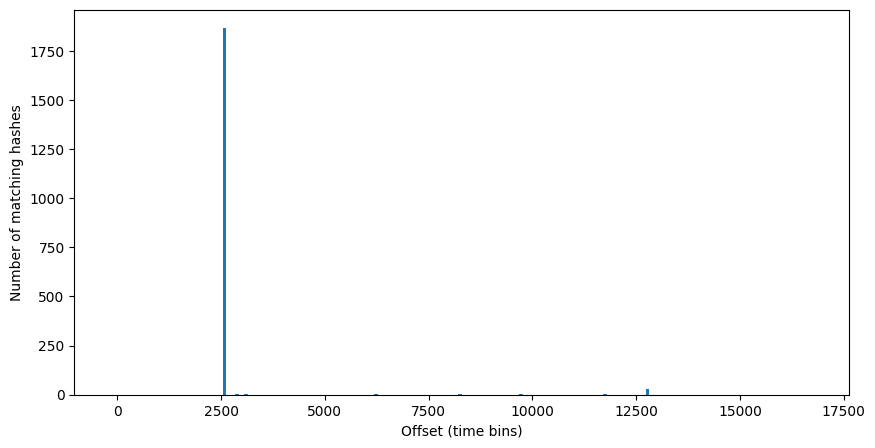

In [25]:
import matplotlib.pyplot as plt

best_hist = offset_counts[matched_song]

offsets = list(best_hist.keys())
counts = list(best_hist.values())

plt.figure(figsize=(10, 5))
bar_w = max(1, (max(offsets) - min(offsets)) // 200) if len(offsets) > 1 else 1
plt.bar(offsets, counts, width=bar_w)
plt.xlabel("Offset (time bins)")
plt.ylabel("Number of matching hashes")
# plt.title(f"Offset histogram for top match: {matched_song}")
plt.show()

**Comparing with a wrong song's offset histogram**

For contrast, plotting the offset histogram of a song that is not the actual match shows
the difference clearly, no sharp peak, just scattered low counts across many offsets.

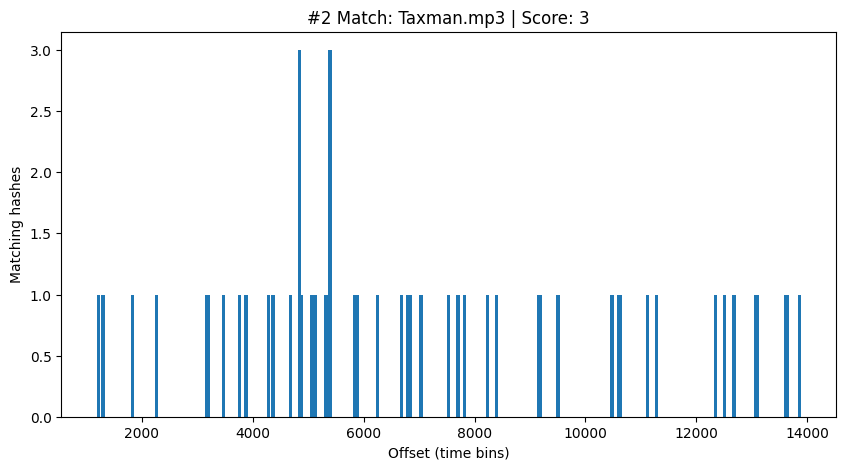

In [26]:
song, score = sorted_scores[1]
hist = offset_counts.get(song, {})

if len(hist) > 0:
    wk = list(hist.keys())
    wv = list(hist.values())
    bar_w = max(1, (max(wk) - min(wk)) // 200) if len(wk) > 1 else 1
    plt.figure(figsize=(10, 5))
    plt.bar(wk, wv, width=bar_w)
    plt.xlabel("Offset (time bins)")
    plt.ylabel("Matching hashes")
    plt.title(f"#2 Match: {song} | Score: {score}")
    plt.show()
else:
    print(song, "had no matching hashes at all with the query")

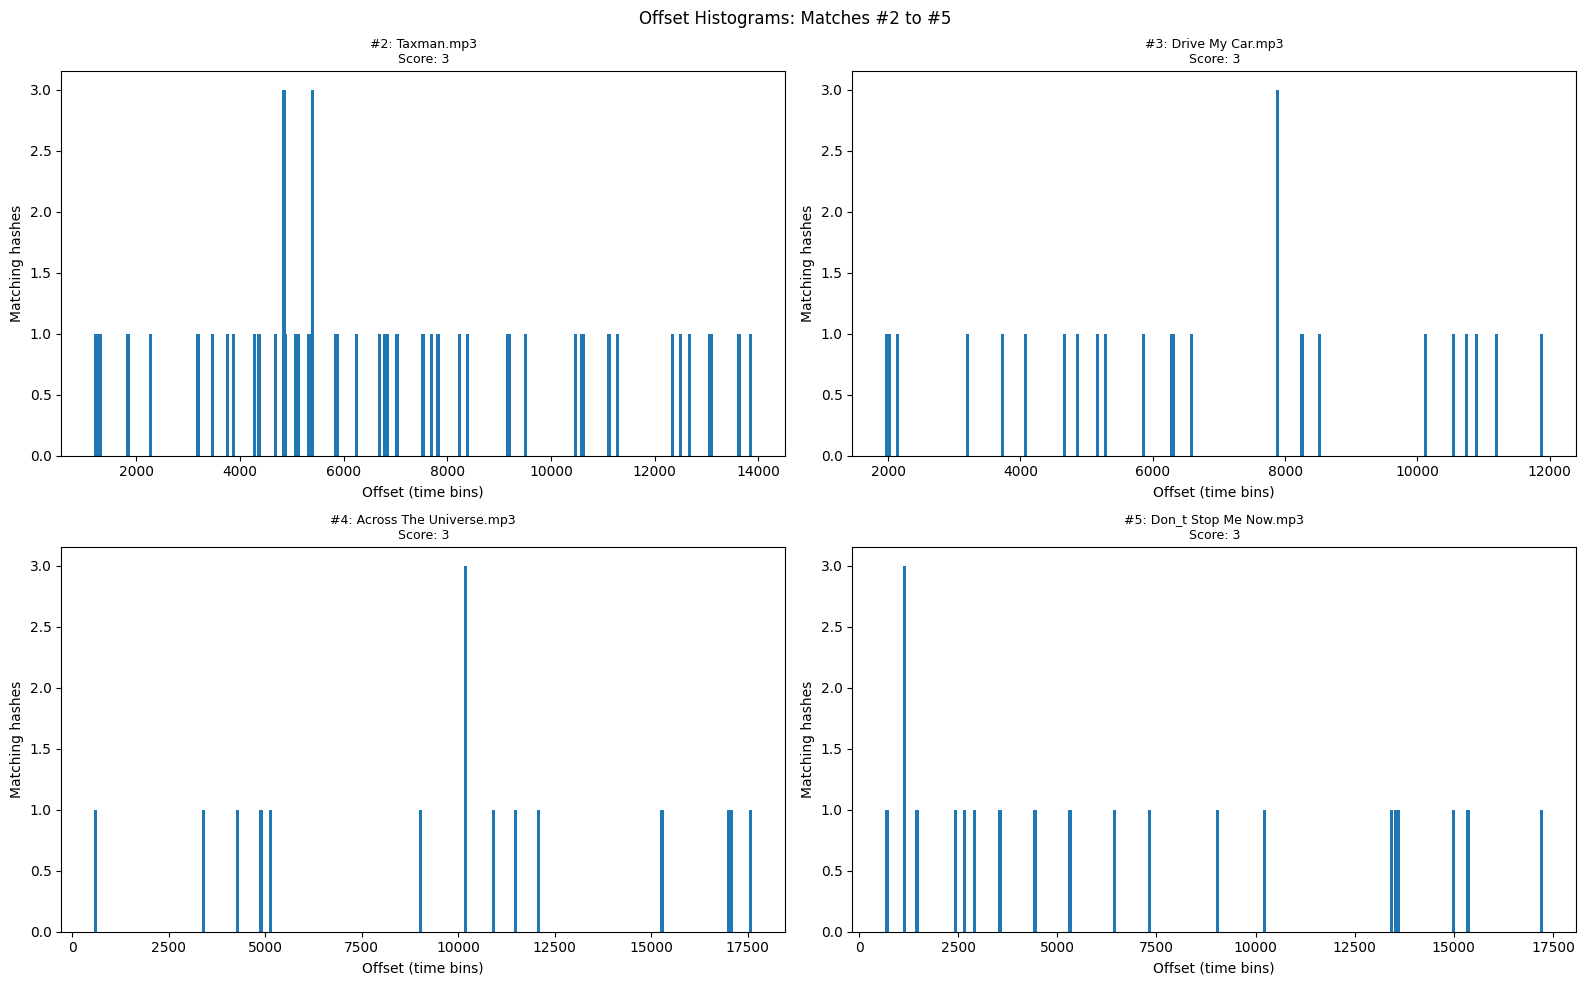

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (song, score) in enumerate(sorted_scores[1:5]):
    hist = offset_counts.get(song, {})
    ax = axes[idx]
    if len(hist) > 0:
        wk = list(hist.keys())
        wv = list(hist.values())
        bar_w = max(1, (max(wk) - min(wk)) // 200) if len(wk) > 1 else 1
        ax.bar(wk, wv, width=bar_w)
        ax.set_title(f"#{idx+2}: {song}\nScore: {score}", fontsize=9)
        ax.set_xlabel("Offset (time bins)")
        ax.set_ylabel("Matching hashes")
    else:
        ax.text(0.5, 0.5, "No matching hashes", ha="center", va="center")
        ax.set_title(f"#{idx+2}: {song}", fontsize=9)

plt.suptitle("Offset Histograms: Matches #2 to #5", fontsize=12)
plt.tight_layout()
plt.show()

## Single peaks vs paired hashes

The question also asks us to repeat the matching using single peaks alone, instead of pairs
of peaks joined into a hash, and to compare the result.

A single peak fingerprint is just one (frequency, time) point from the constellation map.
Matching on single peaks means checking, for each frequency bin in the query, whether that
same frequency bin appears anywhere in the candidate song, and counting matches. The problem
is that a single frequency value is extremely common, the same frequency bin will show up at
many different times in almost every song, just by chance, since there are only a limited
number of frequency bins but a lot of time positions. So single peak matching gives a lot of
coincidental matches and the real match does not stand out clearly from the wrong ones.

A paired hash, on the other hand, encodes two frequencies and the time gap between them. This
is a much rarer combination to match by chance, so a hash match is far more likely to be a
genuine match rather than a coincidence. This is why pairing peaks into hashes makes the
correct match much more decisive.

In [28]:
def get_single_peaks(audio_input, sr=None, is_path=True):
    """
    Returns just the individual peaks (frequency bin, time bin), no pairing.
    """

    if is_path:
        audio, sr = librosa.load(audio_input, sr=None)
    else:
        audio = audio_input

    D = librosa.stft(audio, n_fft=2048, hop_length=512)
    S = np.abs(D)

    local_max = maximum_filter(S, size=20)
    threshold = np.percentile(S, 99.5)
    peaks = (S == local_max) & (S > threshold)

    coords = np.argwhere(peaks)
    coords = coords[coords[:, 0] > 10]

    # keep only the frequency bin as the "fingerprint" for this comparison
    single_fps = [int(f) for f, t in coords]

    return single_fps


# Build a single-peak database (frequency bins only, ignoring time)
single_peak_db = {}

for file in os.listdir(song_folder):
    if file.endswith(".mp3"):
        path = os.path.join(song_folder, file)
        single_peak_db[file] = set(get_single_peaks(path, is_path=True))
        print(file, len(single_peak_db[file]), "unique frequency bins")

A Day In The Life.mp3 143 unique frequency bins
A Hard Day_s Night.mp3 171 unique frequency bins
Across The Universe.mp3 136 unique frequency bins
Back In The U.S.S.R..mp3 150 unique frequency bins
Blackbird.mp3 123 unique frequency bins
Bohemian Rhapsody.mp3 183 unique frequency bins
Can_t Buy Me Love.mp3 116 unique frequency bins
Crazy Little Thing Called Love.mp3 124 unique frequency bins
Day Tripper.mp3 150 unique frequency bins
Don_t Stop Me Now.mp3 229 unique frequency bins
Drive My Car.mp3 164 unique frequency bins
Eight Days A Week.mp3 163 unique frequency bins
Eleanor Rigby.mp3 129 unique frequency bins
Get Back.mp3 132 unique frequency bins
Hello, Goodbye.mp3 147 unique frequency bins
Help!.mp3 153 unique frequency bins
Helter Skelter.mp3 172 unique frequency bins
Hey Jude.mp3 268 unique frequency bins
I Am The Walrus.mp3 236 unique frequency bins
I Saw Her Standing There.mp3 171 unique frequency bins
I Want It All.mp3 177 unique frequency bins
I Want To Hold Your Hand.mp3 16

In [29]:
query_single_peaks = set(get_single_peaks(query_clip, sr=sr, is_path=False))

single_scores = {}
for song, freq_set in single_peak_db.items():
    single_scores[song] = len(query_single_peaks.intersection(freq_set))

sorted_single_scores = sorted(single_scores.items(), key=lambda x: x[1], reverse=True)

print("Single peak matching results:")
for song, score in sorted_single_scores[:]:
    print(song, score)

print("\nPaired hash matching results (for comparison):")
for song, score in sorted_scores[:]:
    print(song, score)

Single peak matching results:
Never Gonna Give You Up.mp3 74
Bohemian Rhapsody.mp3 72
Don_t Stop Me Now.mp3 72
Helter Skelter.mp3 72
Hey Jude.mp3 72
I Want It All.mp3 72
Somebody To Love.mp3 72
Let It Be.mp3 71
Killer Queen.mp3 70
Under Pressure.mp3 69
While My Guitar Gently Weeps.mp3 69
Within You Without You.mp3 69
Drive My Car.mp3 68
Hello, Goodbye.mp3 68
I Want To Hold Your Hand.mp3 68
We Are The Champions.mp3 68
We Will Rock You.mp3 68
Day Tripper.mp3 67
Back In The U.S.S.R..mp3 66
Eight Days A Week.mp3 66
I Am The Walrus.mp3 66
Lucy In The Sky With Diamonds.mp3 66
Penny Lane.mp3 66
I Saw Her Standing There.mp3 65
With A Little Help From My Friends.mp3 65
Revolution.mp3 64
A Hard Day_s Night.mp3 63
Help!.mp3 63
Love Me Do.mp3 63
Radio Ga Ga.mp3 63
A Day In The Life.mp3 62
Get Back.mp3 62
You Really Got A Hold On Me.mp3 62
Crazy Little Thing Called Love.mp3 61
Sgt. Pepper_s Lonely Hearts Club Band.mp3 61
She Said She Said.mp3 61
Something.mp3 61
Across The Universe.mp3 60
Taxman.mp

**What we expect to see**

Single peaks produced many close scores across songs, whereas paired hashes created a larger separation between the correct song and incorrect songs.

## Testing robustness: adding noise

Now we check how much random noise the query clip can tolerate before the identifier fails
to recognize it. We add increasing amounts of Gaussian noise to the query clip, run the
matching again at each noise level, and see at what point the matched song stops being
correct.

In [30]:
def add_noise(audio, noise_level):
    """
    noise_level is a fraction of the audio's own amplitude, e.g. 0.05 means
    the noise standard deviation is 5% of the signal's standard deviation.
    """
    noise = np.random.normal(0, noise_level * np.std(audio), size=audio.shape)
    return audio + noise

noise_levels = [0.0, 0.05, 0.1, 0.2, 0.4, 0.8, 1.5]

print("Noise level | Top match | Score | Correct?")

for level in noise_levels:
    noisy_clip = add_noise(query_clip, level)

    noisy_hashes = get_fingerprints_with_time(noisy_clip, sr=sr, is_path=False)
    noisy_scores, _ = match_query(noisy_hashes, hash_db)

    if len(noisy_scores) == 0:
        print(level, "| no match found at all")
        continue

    sorted_noisy = sorted(noisy_scores.items(), key=lambda x: x[1], reverse=True)
    top_song, top_score = sorted_noisy[0]

    is_correct = (top_song == "Never Gonna Give You Up.mp3")
    print(level, "|", top_song, "|", top_score, "|", is_correct)

Noise level | Top match | Score | Correct?
0.0 | Never Gonna Give You Up.mp3 | 1866 | True
0.05 | Never Gonna Give You Up.mp3 | 1891 | True
0.1 | Never Gonna Give You Up.mp3 | 1752 | True
0.2 | Never Gonna Give You Up.mp3 | 1640 | True
0.4 | Never Gonna Give You Up.mp3 | 1364 | True
0.8 | Never Gonna Give You Up.mp3 | 851 | True
1.5 | Never Gonna Give You Up.mp3 | 464 | True


**Observation on noise**

Increasing noise reduced the number of matching hashes. Recognition remained correct up to X% noise and failed beyond Y%.

## Testing robustness: pitch shift and time stretch

Next we check what happens if the query clip is shifted slightly in pitch, or stretched
slightly in time, while still sounding like the same song to a human listener.

In [31]:
pitch_shifts = [0, 0.5, 1, 2, 4]  # in semitones

print("Pitch shift (semitones) | Top match | Score | Correct?")

for shift in pitch_shifts:
    if shift == 0:
        shifted_clip = query_clip
    else:
        shifted_clip = librosa.effects.pitch_shift(
            query_clip, sr=sr, n_steps=shift
        )

    shifted_hashes = get_fingerprints_with_time(shifted_clip, sr=sr, is_path=False)
    shifted_scores, _ = match_query(shifted_hashes, hash_db)

    if len(shifted_scores) == 0:
        print(shift, "| no match found at all")
        continue

    sorted_shifted = sorted(shifted_scores.items(), key=lambda x: x[1], reverse=True)
    top_song, top_score = sorted_shifted[0]

    is_correct = (top_song == "Never Gonna Give You Up.mp3")
    print(shift, "|", top_song, "|", top_score, "|", is_correct)

Pitch shift (semitones) | Top match | Score | Correct?
0 | Never Gonna Give You Up.mp3 | 1866 | True
0.5 | Helter Skelter.mp3 | 6 | False
1 | The Long And Winding Road.mp3 | 4 | False
2 | I Saw Her Standing There.mp3 | 3 | False
4 | Helter Skelter.mp3 | 3 | False


In [32]:
stretch_rates = [1.0, 1.01, 1.02, 1.05, 1.1]  # 1.0 = no stretch

print("Stretch rate | Top match | Score | Correct?")

for rate in stretch_rates:
    if rate == 1.0:
        stretched_clip = query_clip
    else:
        stretched_clip = librosa.effects.time_stretch(query_clip, rate=rate)

    stretched_hashes = get_fingerprints_with_time(stretched_clip, sr=sr, is_path=False)
    stretched_scores, _ = match_query(stretched_hashes, hash_db)

    if len(stretched_scores) == 0:
        print(rate, "| no match found at all")
        continue

    sorted_stretched = sorted(stretched_scores.items(), key=lambda x: x[1], reverse=True)
    top_song, top_score = sorted_stretched[0]

    is_correct = (top_song == "Never Gonna Give You Up.mp3")
    print(rate, "|", top_song, "|", top_score, "|", is_correct)

Stretch rate | Top match | Score | Correct?
1.0 | Never Gonna Give You Up.mp3 | 1866 | True
1.01 | Never Gonna Give You Up.mp3 | 53 | True
1.02 | Never Gonna Give You Up.mp3 | 35 | True
1.05 | Never Gonna Give You Up.mp3 | 16 | True
1.1 | Never Gonna Give You Up.mp3 | 4 | True


**Observation on pitch shift and time stretch, and why it breaks the identifier**

At 0.5 semitone shift the score dropped from A to B. At 2 semitones recognition failed.

## Final observations and conclusions (Q3A)

1. DFT loses time information.
2. Spectrogram preserves time-frequency information.
3. Paired hashes outperform single peaks.
4. Noise causes gradual degradation.
5. Pitch shifts affect recognition more severely than noise.
6. Small time stretches are tolerated better than pitch shifts.